# Q-Learning for Frozen-walk game

This notebook aims at training, validating and testing a reinforncement learning agent using Q-Learning. The notebook includes:
1. Initiate a Frozen lake environment and an agent.  
2. Train the agent using <b>Q-Learning</b>.  
3. Print out the optimal policy, i.e., what is the best action at a stage.  

Frozen lake involves crossing a frozen lake from start to goal without falling into any holes by walking over the frozen lake. The player may not always move in the intended direction due to the slippery nature of the frozen lake.

![Frozen walk](https://gymnasium.farama.org/_images/frozen_lake.gif)

More details can be found at https://gymnasium.farama.org/environments/toy_text/frozen_lake/.

### Install libraries and initiate a frozen lake map

In [ ]:
# Install gymnasium game environment
!pip install gymnasium
!pip install gymnasium[toy-text]

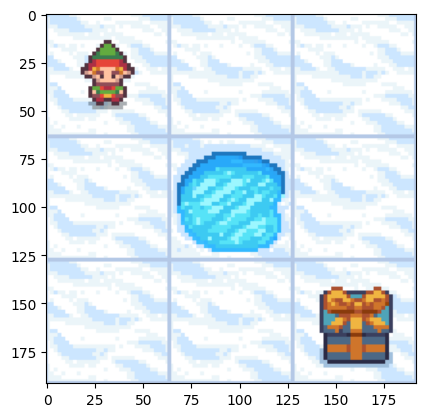

In [ ]:
### Please do not change this code
# Load libraries
import gymnasium as gym
import matplotlib.pyplot as plt

# Define environment map
custom_map = [
    'SFF',
    'FHF',
    'FFG'
]

# Initialize the environment\
env = gym.make('FrozenLake-v1', desc=custom_map, is_slippery=False, render_mode='rgb_array')
state_size = env.observation_space.n    # Number of states
action_size = env.action_space.n    # Number of actions of this game: four, 0: left, 1:down, 2: right, 3: up.
env.reset()    # Reset environment, i.e., set agent position to state 0
plt.imshow(env.render())    # Visualize environment map

# Q-Learning

In [ ]:
import numpy as np

# Initialize Q-table with zeros
Q = np.zeros([state_size, action_size])

# Hyperparameters
alpha = 0.001  # Learning rate
gamma = 0.9  # Discount factor
epsilon = 1.0  # Exploration rate
epsilon_decay = 0.9995  # Decay rate of epsilon after each episode
min_epsilon = 0.1  # Minimum epsilon value
episodes = 30000  # Number of training episodes

# Function to perform Q-learning with epsilon decay
for episode in range(1, episodes + 1):
    state, _ = env.reset()  # Get the initial state
    done = False
    G = 0  # Total reward in this episode

    while not done:
        # Select action based on epsilon-greedy strategy
        if np.random.rand() < epsilon:  # Exploration
            action = env.action_space.sample()
        else:  # Exploitation
            action = np.argmax(Q[state])

        # Take the action and get the new state and reward
        new_state, reward, done, _, _ = env.step(action)

        # Update the Q-table based on the Q-learning formula
        Q[state, action] += alpha * (reward + gamma * np.max(Q[new_state]) - Q[state, action])

        # Update the total reward
        G += reward

        # Move to the next state
        state = new_state

    # Decay epsilon after each episode (gradually reduce exploration)
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

    # Print the sum of rewards every 10 episodes
    if episode % 10 == 0:  # Print less frequently for clarity
        print(f"Episode {episode}, Sum of reward: {G}, Epsilon: {epsilon}")


Episode 10, Sum of reward: 0.0, Epsilon: 0.9950112350131176
Episode 20, Sum of reward: 0.0, Epsilon: 0.9900473578023296
Episode 30, Sum of reward: 0.0, Epsilon: 0.98510824420837
Episode 40, Sum of reward: 0.0, Epsilon: 0.9801937706913741
Episode 50, Sum of reward: 0.0, Epsilon: 0.9753038143277888
Episode 60, Sum of reward: 1.0, Epsilon: 0.9704382528072976
Episode 70, Sum of reward: 1.0, Epsilon: 0.9655969644297613
Episode 80, Sum of reward: 1.0, Epsilon: 0.9607798281021742
Episode 90, Sum of reward: 0.0, Epsilon: 0.9559867233356352
Episode 100, Sum of reward: 0.0, Epsilon: 0.951217530242334
Episode 110, Sum of reward: 0.0, Epsilon: 0.9464721295325524
Episode 120, Sum of reward: 0.0, Epsilon: 0.9417504025116805
Episode 130, Sum of reward: 0.0, Epsilon: 0.937052231077248
Episode 140, Sum of reward: 0.0, Epsilon: 0.9323774977159699
Episode 150, Sum of reward: 0.0, Epsilon: 0.9277260855008077
Episode 160, Sum of reward: 0.0, Epsilon: 0.923097878088044
Episode 170, Sum of reward: 0.0, Epsil

# Print the optimal policy

In [ ]:
def print_optimal_policy(Q, state_size, action_size):
    # Get the optimal action for each state by finding the action with the highest Q-value
    optimal_policy = np.argmax(Q, axis=1)

    # Print the optimal policy for each state
    print("Optimal policy (best action for each state):")
    for state in range(state_size):
        print(f"State {state}: Action {optimal_policy[state]}")

# Assuming Q is your trained Q-table, and the environment has a state space size of 9 (for 3x3 grid)
print_optimal_policy(Q, state_size=9, action_size=4)

Optimal policy (best action for each state):
State 0: Action 1
State 1: Action 2
State 2: Action 1
State 3: Action 1
State 4: Action 0
State 5: Action 1
State 6: Action 2
State 7: Action 2
State 8: Action 0


### Test the environment

In [ ]:
import imageio

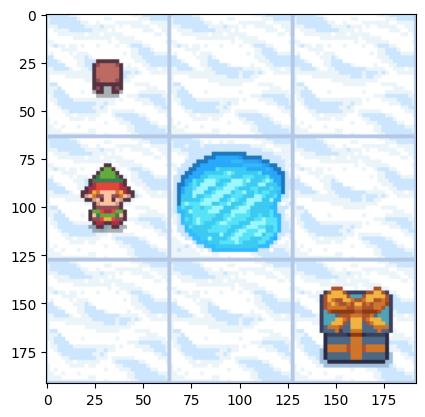

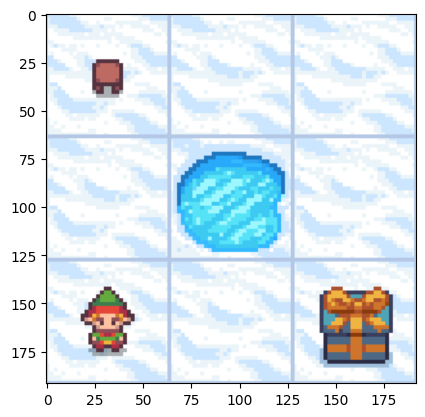

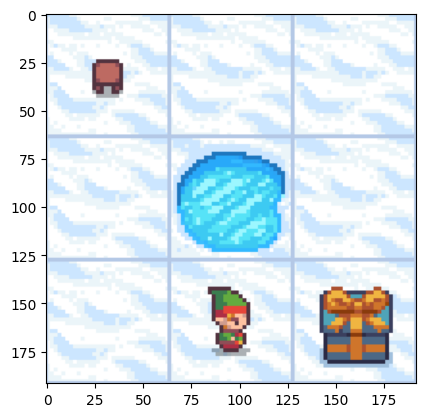

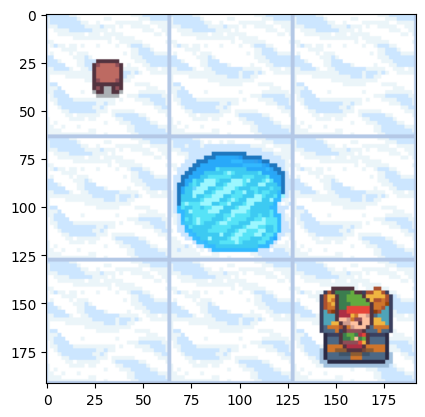

In [ ]:
state=env.reset()[0]
done=False
img_lst = [env.render()]
while not done:
  if np.max(Q[state])>0:
    action=np.argmax(Q[state])
  else:
    action=env.action_space.sample()

  new_state,reward,done,_,_=env.step(action)
  img=env.render()
  img_lst.append(img)
  plt.imshow(img)
  plt.show()
  state=new_state

imageio.mimsave('test.gif', img_lst, format='GIF', duration=1)

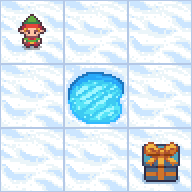

In [ ]:
# Display test result animation
from IPython.display import Image
Image('test.gif')